In [1]:
import cajal.sample_swc
import cajal.swc


In [2]:
#no_metadata = ['639013022', '640006296', '640012241', '661481525', '692310663', '739840659', '740373591', '740401195', '741187985', '742041338',
 #              '742049511', '742054277', '743675437', '743688686', '824909637', '824937690', '831175106', '847876759', '867650384', '869634031',
 #              '889271408', '895740736', '898559010', '898881170', '899368360', '899583778', '904832267', '904862358', '910375338', '912289883', 
  #             '912301547', '912340608', '912868696', '912889454', '912918179', '914412754', '915479566', '919102928', '919699890', '919883526', 
   #            '919950532', '922613228', '924610453', '925242241', '926816093', '926866005', '926887643', '927833265', '929533489', '935046071', 
    #           '936001075', '947344218', '947496055', '950034792', '950075297', '952669499', '954032889', '954045943', '954066469', '962355052',
     #          '962821095', '963019667', '963055521', '963063283']
#dist matrix with only metadata SWCs
cajal.sample_swc.compute_icdm_all_euclidean(
    infolder = "/home/njay/cajal/Data/NewGouwen_pathseq_data/NewGouwen_onlymetadata_swc",
    out_csv="../data/processed/onlymetadata_noaxons_gouwen_patch_seq_100pts_euclidean_icdm.csv",
    preprocess=cajal.swc.preprocessor_eu(
        structure_ids=[1,3,4],
        soma_component_only=False),
    n_sample=100,
    num_processes=8)  # num_processes can be set to the number of cores on your machine


100%|████████████████████████████████████████████████████████████████████████████████▊| 324/325 [01:20<00:00,  4.03it/s]


[]

In [4]:
import cajal.run_gw

cajal.run_gw.compute_gw_distance_matrix(
    "../data/processed/onlymetadata_noaxons_gouwen_patch_seq_100pts_euclidean_icdm.csv",
    "../data/processed/onlymetadata_noaxons_gouwen_patchseq_100pts_euclidean_GW_dmat.csv",
    num_processes=8)


  0%|          | 0/52650 [00:00<?, ?it/s]

(array([[ 0.        , 19.24118091, 16.37523121, ..., 25.09795147,
         31.04310762, 24.51622228],
        [19.24118091,  0.        , 15.74872567, ..., 18.1070255 ,
         14.28600489, 19.2878446 ],
        [16.37523121, 15.74872567,  0.        , ..., 18.97735575,
         24.14337713, 18.79152571],
        ...,
        [25.09795147, 18.1070255 , 18.97735575, ...,  0.        ,
         15.67064477, 18.57578805],
        [31.04310762, 14.28600489, 24.14337713, ..., 15.67064477,
          0.        , 15.63117862],
        [24.51622228, 19.2878446 , 18.79152571, ..., 18.57578805,
         15.63117862,  0.        ]]),
 None)

In [21]:
import plotly.io as pio
pio.renderers.default = 'iframe'

import cajal.utilities
import umap
import plotly.express

# Read GW distance matrix
cells, gw_dist_dict = cajal.utilities.read_gw_dists("../data/processed/onlymetadata_noaxons_gouwen_patchseq_100pts_euclidean_GW_dmat.csv", header=True)
gw_dist = cajal.utilities.dist_mat_of_dict(gw_dist_dict)

# Compute UMAP representation
reducer = umap.UMAP(metric="precomputed", random_state=1)
embedding = reducer.fit_transform(gw_dist)

# Visualize UMAP
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells])

/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1857: UserWarning:

using precomputed metric; inverse_transform will be unavailable

/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [22]:
import plotly.io as pio
import cajal.utilities
import umap
import plotly.express

# Read GW distance matrix
cells, gw_dist_dict = cajal.utilities.read_gw_dists("../data/processed/onlymetadata_noaxons_gouwen_patchseq_100pts_euclidean_GW_dmat.csv", header=True)
gw_dist = cajal.utilities.dist_mat_of_dict(gw_dist_dict)

# Compute UMAP representation
reducer = umap.UMAP(metric="precomputed", random_state=1)
embedding = reducer.fit_transform(gw_dist)

# Set width and height in inches
width_inches = 8
height_inches = 6

# Visualize UMAP with specified width and height
fig = plotly.express.scatter(x=embedding[:, 0],
                             y=embedding[:, 1],
                             template="simple_white",
                             hover_name=[m + ".swc" for m in cells])

# Update layout with width and height
fig.update_layout(
    width=width_inches * 96,  # 96 pixels per inch
    height=height_inches * 96,  # 96 pixels per inch
)

# Show the plot
fig.show()


/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1857: UserWarning:

using precomputed metric; inverse_transform will be unavailable

/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [23]:
clusters = cajal.utilities.leiden_clustering(gw_dist, seed=1)
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells],
                       color = [str(m) for m in clusters])

In [25]:
import pandas
cells_without_suffix = [specimen_id.replace('_transformed', '') for specimen_id in cells]

metadata = pandas.read_csv("../data/raw/NewGouwen_metadata.csv")
metadata.index = [str(m) for m in metadata["Specimen ID"]]
metadata = metadata.loc[cells_without_suffix]
plotly.express.scatter(
        x=embedding[:, 0],
        y=embedding[:, 1],
        template="simple_white",
        hover_name=[m + ".swc" for m in cells_without_suffix],
        color=metadata["T type sub-class"]
)

In [9]:
import pandas
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells_without_suffix],
                       color = metadata["T type"], title = "T type"
                      )

In [12]:
import cajal.laplacian_score
import numpy
import pandas
from scipy.spatial.distance import squareform

# Build indicator matrix
layers = numpy.unique(metadata["T type sub-class"])
indicator = (numpy.array(metadata["T type sub-class"])[:,None] == layers)*1

# Compute the Laplacian score
laplacian = pandas.DataFrame(cajal.laplacian_score.laplacian_scores(indicator,
                                       gw_dist,
                                       numpy.median(squareform(gw_dist)),
                                       permutations = 5000,
                                       covariates = None,
                                       return_random_laplacians = False)[0])
laplacian.index = layers

print(laplacian)

                       feature_laplacians  laplacian_p_values  \
Lamp5 interneuron                0.862438            0.000200   
Pvalb interneuron                1.005944            0.770446   
Sncg interneuron                 1.003814            0.455509   
Sst Chodl interneuron            0.983507            0.000400   
Sst interneuron                  0.979931            0.000200   
Vip interneuron                  0.964658            0.000200   

                       laplacian_q_values  
Lamp5 interneuron                0.000600  
Pvalb interneuron                0.770446  
Sncg interneuron                 0.546611  
Sst Chodl interneuron            0.000600  
Sst interneuron                  0.000600  
Vip interneuron                  0.000600  


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cell_type = numpy.array(metadata["T type sub-class"])

clf = KNeighborsClassifier(metric="precomputed", n_neighbors=10, weights="distance")
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type,cv=cv)

numpy.mean(accuracy)

0.6276923076923078

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cell_type = numpy.array(metadata["T type sub-class"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)

numpy.mean(accuracy)


0.6276923076923077

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cell_type = numpy.array(metadata["T type"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)

numpy.mean(accuracy)


/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/sklearn/model_selection/_split.py:737: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=5.



0.13538461538461538

Mean Accuracy (Random Forest): 0.6184615384615385
Mean Accuracy (Dummy Classifier - Stratified): 0.2953846153846154
Mean Accuracy (Dummy Classifier - Uniform): 0.16615384615384618


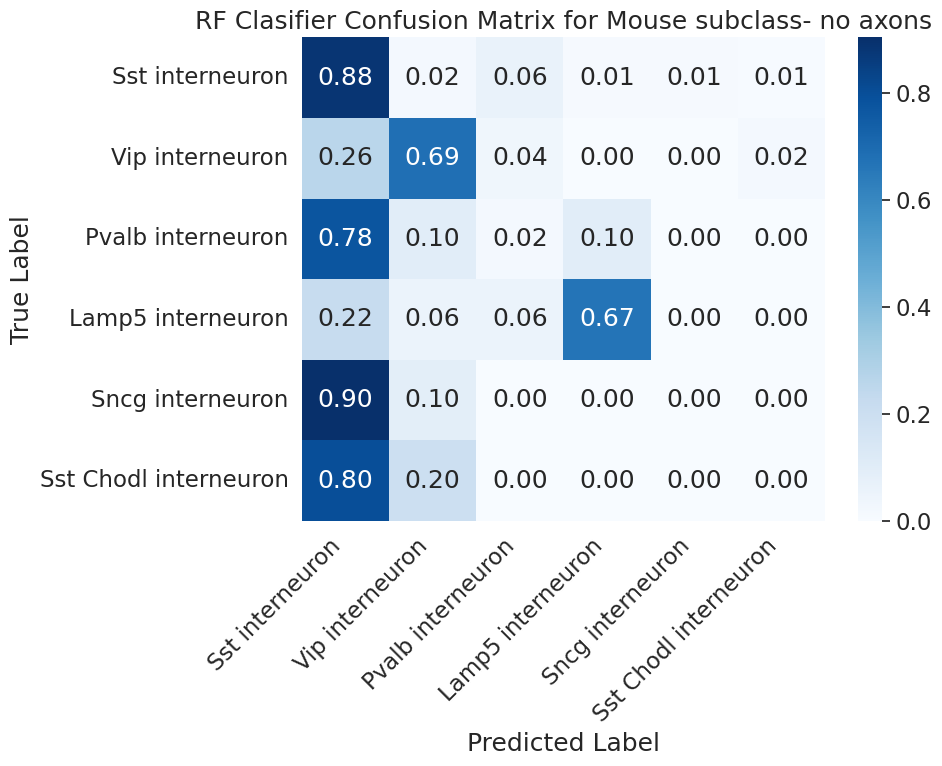

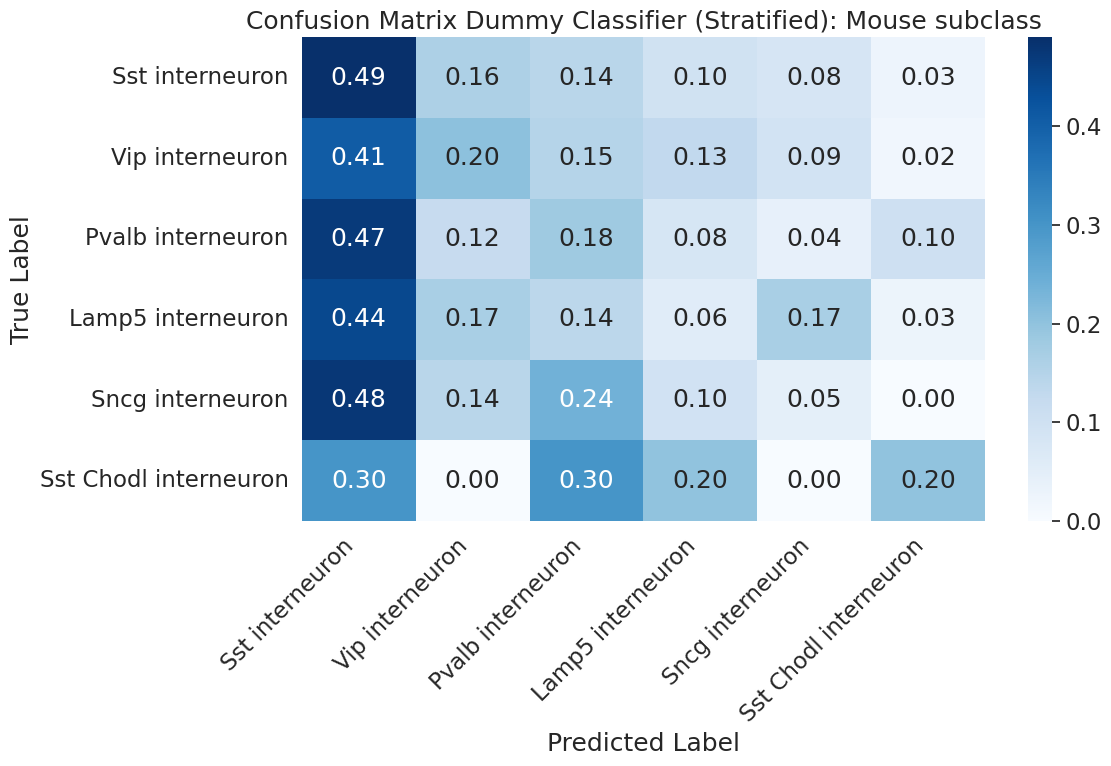

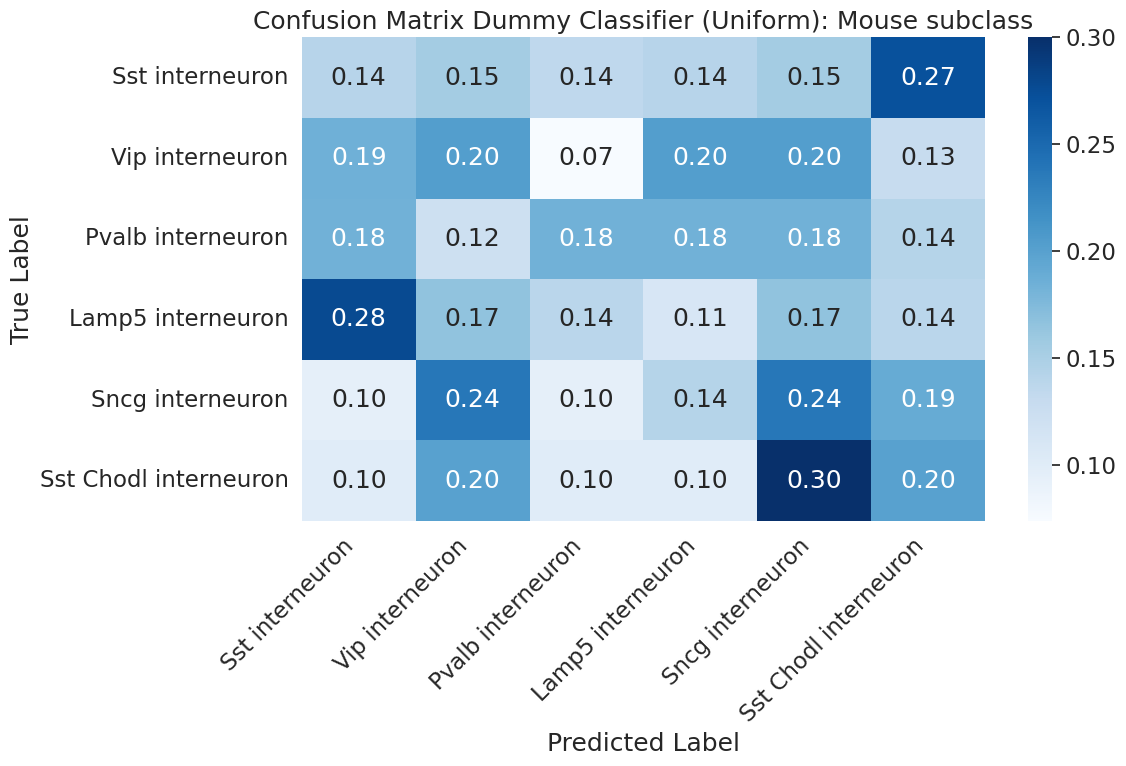

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier

cell_type = np.array(metadata["T type sub-class"])

# Count the occurrences of each class
class_counts = pd.Series(cell_type).value_counts()

# Filter classes with at least 5 occurrences
selected_classes = class_counts[class_counts >= 5].index

# Filter the metadata and feature matrix based on selected classes
class_indices = metadata["T type sub-class"].isin(selected_classes)
filtered_metadata = metadata[class_indices]
filtered_gw_dist = gw_dist[class_indices, :]

# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)

# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True)

# Evaluate RandomForestClassifier
accuracy_rf = cross_val_score(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
mean_accuracy_rf = np.mean(accuracy_rf)

# Generate random baselines
dummy_strat = DummyClassifier(strategy="stratified")
dummy_uniform = DummyClassifier(strategy="uniform")

accuracy_dummy_strat = cross_val_score(dummy_strat, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
accuracy_dummy_uniform = cross_val_score(dummy_uniform, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)

mean_accuracy_dummy_strat = np.mean(accuracy_dummy_strat)
mean_accuracy_dummy_uniform = np.mean(accuracy_dummy_uniform)

# Print mean accuracies
print("Mean Accuracy (Random Forest):", mean_accuracy_rf)
print("Mean Accuracy (Dummy Classifier - Stratified):", mean_accuracy_dummy_strat)
print("Mean Accuracy (Dummy Classifier - Uniform):", mean_accuracy_dummy_uniform)

# Plotting Confusion Matrix for RandomForestClassifier
predictions_rf = cross_val_predict(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
conf_mat_rf = confusion_matrix(cell_type[class_indices], predictions_rf, labels=selected_classes)
conf_mat_percentage_rf = conf_mat_rf / conf_mat_rf.sum(axis=1)[:, np.newaxis]
conf_mat_df_rf = pd.DataFrame(conf_mat_percentage_rf, index=selected_classes, columns=selected_classes)

plt.figure(figsize=(10,8))
sns. set(font_scale=1.5)
sns.heatmap(conf_mat_df_rf, annot=True, cmap="Blues", fmt=".2f")
plt.title("RF Clasifier Confusion Matrix for Mouse subclass- no axons")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
# If labels are still being cut off or not visible, you can adjust them like this
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to fit all elements
plt.show()

# Plotting Confusion Matrix for Dummy Classifier - Stratified
predictions_dummy_strat = cross_val_predict(dummy_strat, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
conf_mat_dummy_strat = confusion_matrix(cell_type[class_indices], predictions_dummy_strat, labels=selected_classes)
conf_mat_percentage_dummy_strat = conf_mat_dummy_strat / conf_mat_dummy_strat.sum(axis=1)[:, np.newaxis]
conf_mat_df_dummy_strat = pd.DataFrame(conf_mat_percentage_dummy_strat, index=selected_classes, columns=selected_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat_df_dummy_strat, annot=True, cmap="Blues", fmt=".2f")
plt.title("Confusion Matrix Dummy Classifier (Stratified): Mouse subclass")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
# If labels are still being cut off or not visible, you can adjust them like this
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to fit all elements
plt.show()

# Plotting Confusion Matrix for Dummy Classifier - Uniform
predictions_dummy_uniform = cross_val_predict(dummy_uniform, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
conf_mat_dummy_uniform = confusion_matrix(cell_type[class_indices], predictions_dummy_uniform, labels=selected_classes)
conf_mat_percentage_dummy_uniform = conf_mat_dummy_uniform / conf_mat_dummy_uniform.sum(axis=1)[:, np.newaxis]
conf_mat_df_dummy_uniform = pd.DataFrame(conf_mat_percentage_dummy_uniform, index=selected_classes, columns=selected_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat_df_dummy_uniform, annot=True, cmap="Blues", fmt=".2f")
plt.title("Confusion Matrix Dummy Classifier (Uniform): Mouse subclass")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
# If labels are still being cut off or not visible, you can adjust them like this
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to fit all elements
plt.show()
